Author: Malcolm Zartman
Public link: https://colab.research.google.com/drive/1jak2huqKpH4nC9MQTbH9VZrkwh8M5srn?usp=sharing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from keras import Sequential
from keras.layers import Dense, Activation
from keras.initializers import Zeros, RandomNormal, glorot_normal, glorot_uniform

In [ ]:
n_input = 784
n_dense = 256
b_init = Zeros()
w_init1 = RandomNormal(stddev=1.0)
w_init2 = glorot_normal()
w_init3 = glorot_uniform()

function1 = 'sigmoid'
function2 = 'tanh'
function3 = 'relu'

In [ ]:
def model_train(w, activ):
  model = Sequential()
  model.add(Dense(n_dense,
                  input_dim=n_input,
                  kernel_initializer=w,
                  bias_initializer=b_init))
  model.add(Activation(activ))
  return model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


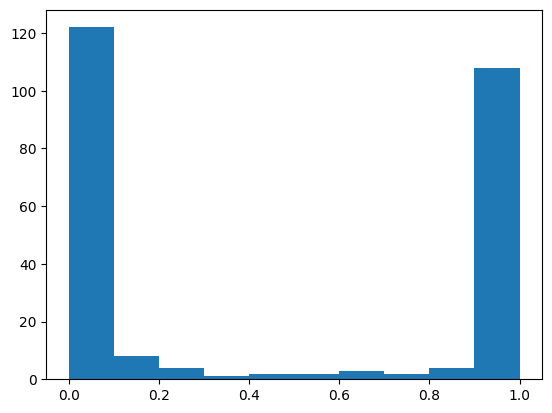

In [ ]:
def predict_n_visualize(w, func):
  x = np.random.random((1,n_input))
  mo = model_train(w, func)
  a = mo.predict(x)
  _ = plt.hist(np.transpose(a))
predict_n_visualize(w_init1, function1)

The result of the chosen weight & activation function lended an extreme bias. This is not a desired result, we want the sigmoid activation function to be more heavily dense in the non-saturated range, so from 0.2-0.8; a bell-shaped curve would be the desired result. This result also tells us that the weights are probably set to be too large.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


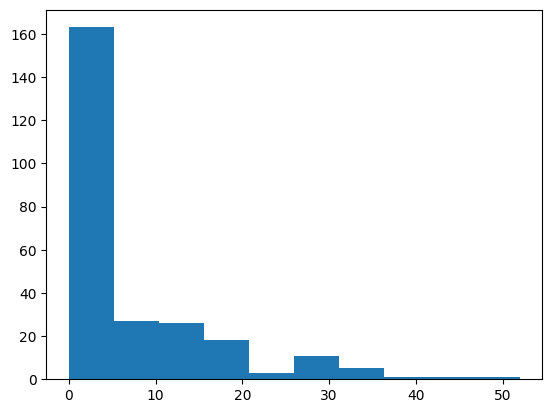

In [ ]:
model_train(w_init1, 'relu')
predict_n_visualize(w_init1, 'relu')

This is on the more healthy side of a result. This is as expected for a ReLU activation function since all negative numbers are turned to 0. However, we don't want it to be too heavy on 0 since that would indicate more of a dead ReLU. And a dead ReLU means that the activation function had most of the inputs being negative (where the linear combination of weights and inputs are negative or 0). So something like a leaky relu may be a better choice. And after assessing the other ReLU function, I noticed the sharp difference in the value range. This one is going from 0 to 40 which further hints at the weights being too large.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


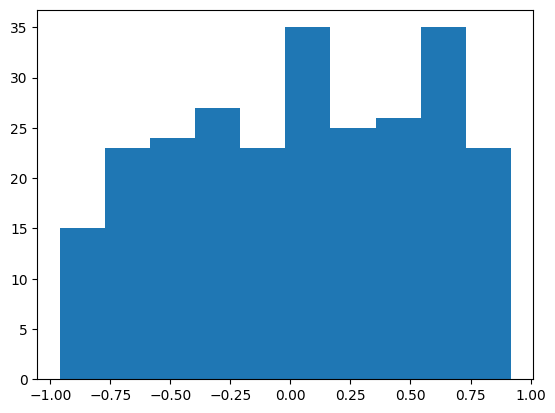

In [ ]:
model_train(w_init2, function2)
predict_n_visualize(w_init2, function2)

This is much better than the sigmoid activation function. This is more of a bell shaped curve distribution which is what we want to see from the tanh function. It could be a bit better with more density in around 0 and more of a drop off towards the -1 and 1 values, however, this is still good.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


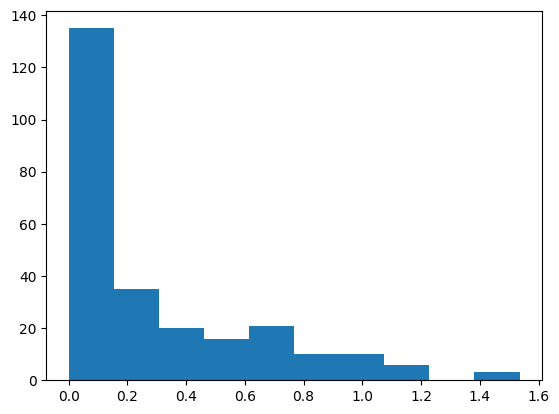

In [ ]:
model_train(w_init3, function3)
predict_n_visualize(w_init3, function3)

While it is still relatively heavy in the 0 range, this is a much healthier distribution for the ReLU function. Especially since the value range is from 0 to 2.